<a href="https://colab.research.google.com/github/Wendell9/N1_IA/blob/main/Modelo_N1_1%C2%BABIMESTRE_ipynb_json.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N1 - Inteligência Artificial

Regressão Linear

Nomes:

[Colocar nome e RA dos integrantes do grupo]

*Orientações:*

Esse arquivo contem o modelo esperado de respostas para a N1. Podem ser acrescentadas algumas outras informações ou trechos com códigos, entretanto não esqueçam de responder todos os pontos que foram levantados a seguir

## Exercício X

1. Carregar os dataset do exercício:

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_white_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-white.csv'

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_red_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-red.csv'

# Carrega o dataset diretamente do GitHub para um DataFrame do pandas
df_redWine = pd.read_csv(github_csv_url_red_wine,sep = ";")
df_whiteWine = pd.read_csv(github_csv_url_white_wine,sep = ";")

2. Fazer a análise exploratória dos dados

(Espera-se no minimo que seja verificado os tipos de dados envolvidos e suas médias, desvios padrões e distribuição dos dados - função describe())

In [2]:
df_redWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [3]:
df_whiteWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [4]:
df_whiteWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [5]:
df_redWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df_whiteWine.shape

(4898, 12)

In [7]:
df_whiteWine.duplicated().sum()

np.int64(937)

In [8]:
df_redWine.duplicated().sum()

np.int64(240)

In [9]:
df_whiteWine[df_whiteWine.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.900000,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.100000,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.800000,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.500000,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.800000,8
...,...,...,...,...,...,...,...,...,...,...,...,...
4828,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
4850,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
4851,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
4856,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [10]:
df_redWine[df_redWine.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


Os itens considerados 'duplicados' tratam-se de vinhos com os mesmos valores de variáveis e entendo que não necessariamente são duplicados, mas serão dropados justamente pela duplicação de valores que nao serão de valia para o treinamento do modelo, uma vez que podem gerar overfitting e peso desproporcional para determinados padrões.

In [11]:
#df_whiteWine.drop_duplicates(inplace=True)
#df_whiteWine.shape

In [12]:
corr_matrix=df_whiteWine.corr()
corr_matrix['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.435575
pH,0.099427
sulphates,0.053678
free sulfur dioxide,0.008158
citric acid,-0.009209
residual sugar,-0.097577
fixed acidity,-0.113663
total sulfur dioxide,-0.174737
volatile acidity,-0.194723


OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

As features são alcohol, pH,sulphates,free sulfur dioxide,citric acid, residual sugar, fixed acidity, total sulfur dioxide, chiorides,density. Por sua vez, a variável alvo é quality.

3. Dividir os dados em conjunto de treinamento e teste e fazer a regressão com pelo menos três modelos diferentes

In [13]:
# Define X by dropping only the target variable 'quality'
# All other columns in df_whiteWineTratado should now be treated as features,
# including the new custom, log-transformed, and polynomial features.
X = df_whiteWine.drop(columns=['quality'])
y = df_whiteWine['quality']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

# Regressão Linear

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Padronize os dados de treino e teste
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lin = LinearRegression()

scores = cross_val_score(
    model_lin, X_train_scaled, y_train, cv=5, scoring='r2'
)

model_lin.fit(X_train_scaled, y_train)

y_pred_lin = model_lin.predict(X_test_scaled)

# Arvore de Decisão

In [16]:
X = df_whiteWine.drop(columns=['quality'])
y = df_whiteWine['quality']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

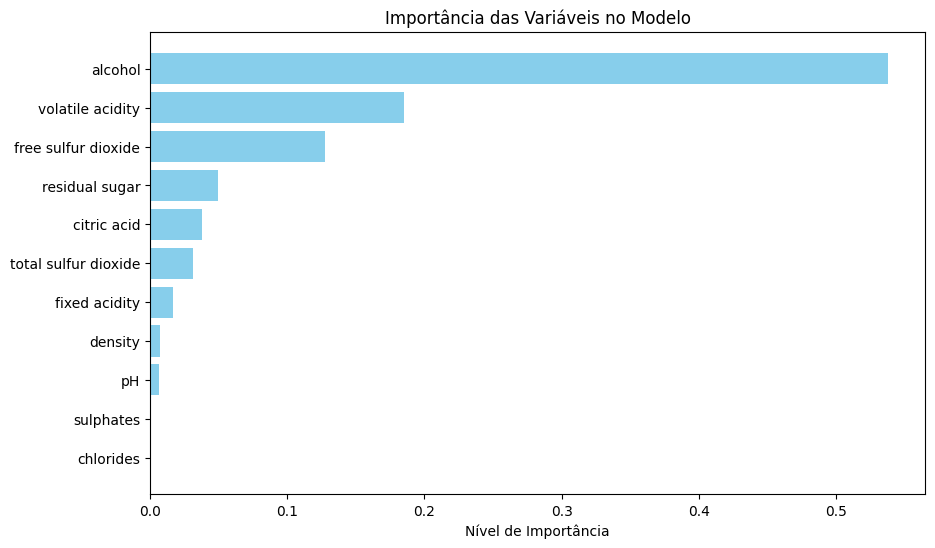

In [19]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

model_dtr = DecisionTreeRegressor(random_state=42, max_depth=5)
scores = cross_val_score(
    model_dtr, X_train, y_train, cv=5, scoring='r2'
)
model_dtr.fit(X_train, y_train)

y_pred_dtr = model_dtr.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_dtr.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Random Forest

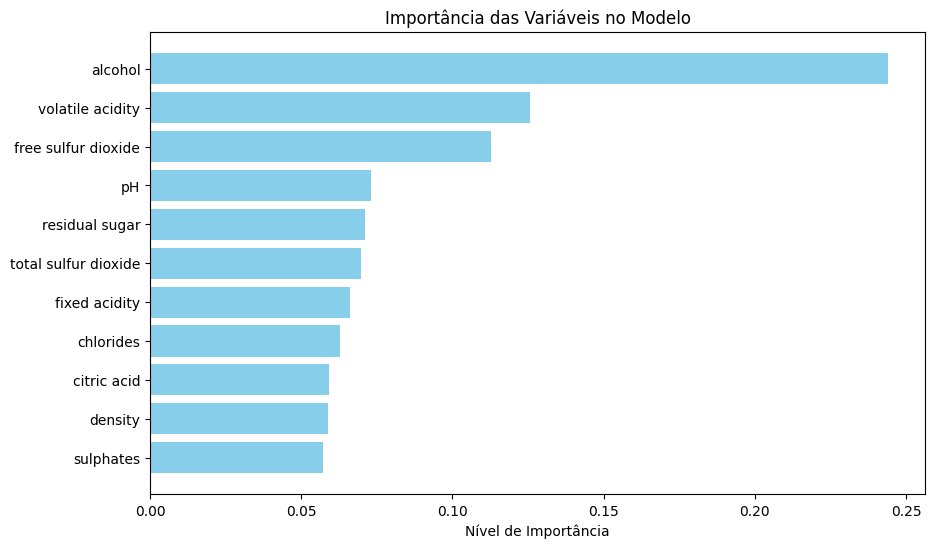

In [20]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(
    model_rf, X_train, y_train, cv=5, scoring='r2'
)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_rf.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Suport Vector Regressor (SVR)

In [21]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 1. Padronize os dados de treino e teste para SVR
scaler_svr = StandardScaler()
X_train_scaled_svr = scaler_svr.fit_transform(X_train)
X_test_scaled_svr = scaler_svr.transform(X_test)

model_svr = SVR(kernel='rbf', C=100, gamma=0.1)

scores = cross_val_score(
    model_svr, X_train_scaled_svr, y_train, cv=5, scoring='r2'
)

model_svr.fit(X_train_scaled_svr, y_train)

y_pred_svr = model_svr.predict(X_test_scaled_svr)

# XGBoost Regressor

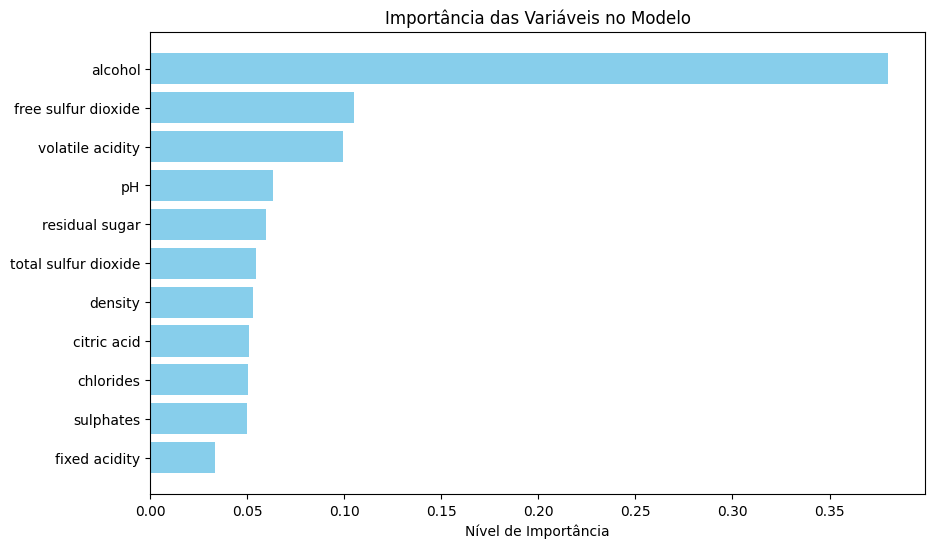

In [22]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

scores = cross_val_score(
    model_xgb, X_train, y_train, cv=5, scoring='r2'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

# 3. Extraia a importância e crie um DataFrame para visualizar
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_xgb.feature_importances_
})

# 4. Ordene da maior para a menor importância
importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

4. Metricas de desempenho

(Usar as métricas de desempenho para comparar os resultados)

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(y_true, y_pred, model_name=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  MSE = {mse:.4f}")
    print(f"  MAE = {mae:.4f}")
    print(f"  R²  = {r2:.4f}")
    print("-"*30)

# Métricas para cada modelo
print_metrics(y_test, y_pred_lin, "LinearRegression")
print_metrics(y_test, y_pred_dtr, "DecisionTreeRegressor")
print_metrics(y_test, y_pred_rf,  "RandomForestRegressor")
print_metrics(y_test, y_pred_svr, "SVR")
print_metrics(y_test, y_pred_xgb, "XGBRegressor")



LinearRegression:
  MSE = 0.5794
  MAE = 0.5909
  R²  = 0.2619
------------------------------
DecisionTreeRegressor:
  MSE = 0.5372
  MAE = 0.5674
  R²  = 0.3157
------------------------------
RandomForestRegressor:
  MSE = 0.3841
  MAE = 0.4454
  R²  = 0.5107
------------------------------
SVR:
  MSE = 0.6314
  MAE = 0.5575
  R²  = 0.1956
------------------------------
XGBRegressor:
  MSE = 0.4304
  MAE = 0.5055
  R²  = 0.4517
------------------------------


### Otimização de Hiperparâmetros com GridSearchCV

A otimização de hiperparâmetros é o processo de encontrar a combinação ideal de configurações para um modelo de aprendizado de máquina que resulte no melhor desempenho. O `GridSearchCV` do scikit-learn realiza uma busca exaustiva por todas as combinações de hiperparâmetros especificadas, avaliando cada uma delas usando validação cruzada para encontrar a melhor. Isso pode ser computacionalmente caro, mas é uma maneira eficaz de ajustar o modelo.

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Defina uma grade de hiperparâmetros para buscar
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Número de árvores na floresta
    'max_depth': [None, 10, 20],      # Profundidade máxima da árvore
    'min_samples_split': [2, 5, 10],  # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4]     # Número mínimo de amostras em um nó folha
}

model_rf_base = RandomForestRegressor(random_state=42)

# Configure o GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=model_rf_base,
    param_grid=param_grid_rf,
    cv=3,  # Usar 3-fold cross-validation para agilizar, mas 5 é comum
    scoring='r2',
    n_jobs=-1, # Usar todos os núcleos da CPU disponíveis
    verbose=1 # Mostrar progresso
)

print("Iniciando a busca de hiperparâmetros para RandomForestRegressor...")
# Execute a busca
grid_search_rf.fit(X_train, y_train)

print("Busca concluída!")

# Imprima os melhores parâmetros e a melhor pontuação
print(f"Melhores parâmetros para RandomForestRegressor: {grid_search_rf.best_params_}")
print(f"Melhor R² para RandomForestRegressor: {grid_search_rf.best_score_:.4f}")

# Faça previsões com o melhor modelo
y_pred_rf_tuned = grid_search_rf.best_estimator_.predict(X_test)

# Imprima as métricas do modelo otimizado
print_metrics(y_test, y_pred_rf_tuned, "RandomForestRegressor Otimizado")

Iniciando a busca de hiperparâmetros para RandomForestRegressor...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Busca concluída!
Melhores parâmetros para RandomForestRegressor: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Melhor R² para RandomForestRegressor: 0.4713
RandomForestRegressor Otimizado:
  MSE = 0.3791
  MAE = 0.4420
  R²  = 0.5171
------------------------------


### Engenharia de Features (Feature Engineering)

A Engenharia de Features envolve a criação de novas variáveis a partir das variáveis existentes no dataset. O objetivo é ajudar o modelo a capturar padrões mais complexos e relações não-lineares que as features originais sozinhas poderiam não expressar. Isso pode incluir transformações (logarítmicas, polinomiais), interações entre features ou a combinação de várias features em uma nova. Um bom feature engineering pode levar a melhorias significativas no desempenho do modelo.

In [25]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# Vamos criar algumas features novas para o nosso dataset de vinhos.
# Primeiro, vamos garantir que estamos usando o DataFrame original 'df_whiteWine'
# e que as colunas 'X' e 'y' são atualizadas com as novas features.

# Exemplo 1: Relação Álcool-Densidade
# A densidade e o álcool são importantes, a razão entre eles pode ser informativa.
df_whiteWine['alcohol_density_ratio'] = df_whiteWine['alcohol'] / df_whiteWine['density']

# Exemplo 2: Interação entre Ácido Cítrico e Acidez Fixa/Volátil
# O ácido cítrico pode interagir com os níveis de acidez.
df_whiteWine['fixed_citric_acid_interaction'] = df_whiteWine['fixed acidity'] * df_whiteWine['citric acid']
df_whiteWine['volatile_citric_acid_interaction'] = df_whiteWine['volatile acidity'] * df_whiteWine['citric acid']

# Exemplo 3: Total de Dióxido de Enxofre por Dióxido de Enxofre Livre (razão)
# Pode indicar a proporção de SO2 ligado.
df_whiteWine['total_free_sulfur_dioxide_ratio'] = df_whiteWine['total sulfur dioxide'] / (df_whiteWine['free sulfur dioxide'] + 1e-6) # Adiciona epsilon para evitar divisão por zero

# Exemplo 4: Features Polinomiais para algumas variáveis importantes
# Vamos pegar as 3 features mais importantes da Random Forest original: alcohol, volatile acidity, free sulfur dioxide
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_whiteWine[['alcohol', 'volatile acidity', 'free sulfur dioxide']])
poly_feature_names = poly.get_feature_names_out(['alcohol', 'volatile acidity', 'free sulfur dioxide'])

df_poly_features = pd.DataFrame(poly_features, columns=poly_feature_names, index=df_whiteWine.index)

# Juntar as novas features com o DataFrame original
df_whiteWine_fe = pd.concat([df_whiteWine, df_poly_features], axis=1)

# Remover a coluna 'quality' antes de definir X
X_fe = df_whiteWine_fe.drop(columns=['quality'])
y_fe = df_whiteWine_fe['quality']

# Dividir os dados com as novas features em treino e teste
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

print("DataFrame com novas features criado (df_whiteWine_fe) e dados divididos em X_train_fe, X_test_fe, y_train_fe, y_test_fe.")
print(f"Novas dimensões de X_fe: {X_fe.shape}")

# Exibir as primeiras linhas do DataFrame com as novas features
display(df_whiteWine_fe.head())

DataFrame com novas features criado (df_whiteWine_fe) e dados divididos em X_train_fe, X_test_fe, y_train_fe, y_test_fe.
Novas dimensões de X_fe: (4898, 24)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,total_free_sulfur_dioxide_ratio,alcohol,volatile acidity,free sulfur dioxide,alcohol^2,alcohol volatile acidity,alcohol free sulfur dioxide,volatile acidity^2,volatile acidity free sulfur dioxide,free sulfur dioxide^2
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,...,3.777778,8.8,0.27,45.0,77.44,2.376,396.0,0.0729,12.15,2025.0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,...,9.428571,9.5,0.30,14.0,90.25,2.850,133.0,0.0900,4.20,196.0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,...,3.233333,10.1,0.28,30.0,102.01,2.828,303.0,0.0784,8.40,900.0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,...,3.957447,9.9,0.23,47.0,98.01,2.277,465.3,0.0529,10.81,2209.0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,...,3.957447,9.9,0.23,47.0,98.01,2.277,465.3,0.0529,10.81,2209.0


Agora que as novas features foram criadas e os dados foram divididos em conjuntos de treino e teste (`X_train_fe`, `X_test_fe`, `y_train_fe`, `y_test_fe`), podemos treinar e avaliar os modelos novamente usando esses novos dados para ver se houve uma melhoria no desempenho. Que tal re-treinar o `RandomForestRegressor` com esses dados enriquecidos?

### Re-treinando e Avaliando Modelos com Engenharia de Features

#### 1. Regressão Linear com Features Engenheiradas

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Padronize os dados de treino e teste com as features engenheiradas
scaler_lin_fe = StandardScaler()
X_train_scaled_lin_fe = scaler_lin_fe.fit_transform(X_train_fe)
X_test_scaled_lin_fe = scaler_lin_fe.transform(X_test_fe)

model_lin_fe = LinearRegression()

scores_lin_fe = cross_val_score(
    model_lin_fe, X_train_scaled_lin_fe, y_train_fe, cv=5, scoring='r2'
)

model_lin_fe.fit(X_train_scaled_lin_fe, y_train_fe)

y_pred_lin_fe = model_lin_fe.predict(X_test_scaled_lin_fe)

print_metrics(y_test_fe, y_pred_lin_fe, "LinearRegression com FE")

LinearRegression com FE:
  MSE = 0.5402
  MAE = 0.5754
  R²  = 0.3119
------------------------------


#### 2. Árvore de Decisão com Features Engenheiradas

In [27]:
from sklearn.tree import DecisionTreeRegressor

model_dtr_fe = DecisionTreeRegressor(random_state=42, max_depth=5)
scores_dtr_fe = cross_val_score(
    model_dtr_fe, X_train_fe, y_train_fe, cv=5, scoring='r2'
)
model_dtr_fe.fit(X_train_fe, y_train_fe)

y_pred_dtr_fe = model_dtr_fe.predict(X_test_fe)

print_metrics(y_test_fe, y_pred_dtr_fe, "DecisionTreeRegressor com FE")

DecisionTreeRegressor com FE:
  MSE = 0.5589
  MAE = 0.5743
  R²  = 0.2880
------------------------------


#### 3. Random Forest com Features Engenheiradas (e Hiperparâmetros Otimizados)

In [28]:
from sklearn.ensemble import RandomForestRegressor

# Usando os melhores parâmetros encontrados anteriormente:
# grid_search_rf.best_params_ = {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

model_rf_fe = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

scores_rf_fe = cross_val_score(
    model_rf_fe, X_train_fe, y_train_fe, cv=5, scoring='r2'
)
model_rf_fe.fit(X_train_fe, y_train_fe)

y_pred_rf_fe = model_rf_fe.predict(X_test_fe)

print_metrics(y_test_fe, y_pred_rf_fe, "RandomForestRegressor (Otimizado + FE)")

RandomForestRegressor (Otimizado + FE):
  MSE = 0.3743
  MAE = 0.4436
  R²  = 0.5233
------------------------------


#### 4. Suport Vector Regressor (SVR) com Features Engenheiradas

In [29]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Padronize os dados de treino e teste com as features engenheiradas para SVR
scaler_svr_fe = StandardScaler()
X_train_scaled_svr_fe = scaler_svr_fe.fit_transform(X_train_fe)
X_test_scaled_svr_fe = scaler_svr_fe.transform(X_test_fe)

model_svr_fe = SVR(kernel='rbf', C=100, gamma=0.1)

scores_svr_fe = cross_val_score(
    model_svr_fe, X_train_scaled_svr_fe, y_train_fe, cv=5, scoring='r2'
)

model_svr_fe.fit(X_train_scaled_svr_fe, y_train_fe)

y_pred_svr_fe = model_svr_fe.predict(X_test_scaled_svr_fe)

print_metrics(y_test_fe, y_pred_svr_fe, "SVR com FE")

SVR com FE:
  MSE = 0.7136
  MAE = 0.5818
  R²  = 0.0910
------------------------------


#### 5. XGBoost Regressor com Features Engenheiradas

In [30]:
from xgboost import XGBRegressor

model_xgb_fe = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

scores_xgb_fe = cross_val_score(
    model_xgb_fe, X_train_fe, y_train_fe, cv=5, scoring='r2'
)

model_xgb_fe.fit(X_train_fe, y_train_fe)

y_pred_xgb_fe = model_xgb_fe.predict(X_test_fe)

print_metrics(y_test_fe, y_pred_xgb_fe, "XGBRegressor com FE")

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/xgboost/core.py", line 569, in inner_f
    return func(**kwargs)
  File "/usr/local/lib/python3.13/dist-packages/xgboost/sklearn.py", line 1405, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ~~~~~~~~~~~~~~~~~~~~~~~~~^
        missing=self.missing,
        ^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
        feature_types=feature_types,
      

Agora que todos os modelos foram re-treinados com as features engenheiradas, você pode comparar as métricas de desempenho (`MSE`, `MAE`, `R²`) de cada um para ver se a engenharia de features trouxe melhorias em relação aos modelos originais.

5. Conclusão

Qual dos modelos conseguiu o melhor desempenho?